In [1]:
!pip install pandas numpy matplotlib scikit-learn
print("✅ Libraries installed!")


✅ Libraries installed!


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import random
import smtplib
from datetime import datetime, timedelta
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("✅ All libraries imported!")
print(f"📅 System Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("🏦 UAE Banking Compliance Automation System - READY")

✅ All libraries imported!
📅 System Date: 2026-06-02 12:24:37
🏦 UAE Banking Compliance Automation System - READY


Generating Banking data

In [3]:
def generate_transactions(n=10000):
    np.random.seed(42)
    random.seed(42)

    customer_ids = [f"CUS{str(i).zfill(5)}" for i in range(1, 501)]  # 500 customers
    transaction_types = ["TRANSFER", "WITHDRAWAL", "DEPOSIT", "PAYMENT", "LOAN_REPAY"]
    currencies = ["AED", "USD", "EUR", "GBP", "SAR", "INR", "PKR"]
    branches = ["Dubai_Main", "Abu_Dhabi", "Sharjah", "JLT", "DIFC",
                "Deira", "Bur_Dubai", "Jumeirah", "RAK", "Fujairah"]
    nationalities = ["UAE", "Indian", "Pakistani", "British",
                     "Egyptian", "Filipino", "American"]

    records = []
    base_date = datetime(2024, 1, 1)

    for i in range(n):
        amount = round(np.random.exponential(scale=15000), 2)
        records.append({
            "transaction_id":   f"TXN{str(i+1).zfill(7)}",
            "customer_id":      random.choice(customer_ids),
            "nationality":      random.choice(nationalities),
            "transaction_date": (base_date + timedelta(days=random.randint(0, 364))).strftime("%Y-%m-%d"),
            "transaction_type": random.choice(transaction_types),
            "amount":           amount,
            "currency":         random.choice(currencies),
            "branch":           random.choice(branches),
            "status":           random.choices(["COMPLETED","PENDING","FAILED","FLAGGED"],
                                               weights=[70,10,10,10])[0],
            "aml_flag":         random.choices([0, 1], weights=[90, 10])[0],
            "kyc_verified":     random.choices([1, 0], weights=[85, 15])[0],
            "account_type":     random.choices(["PERSONAL","CORPORATE","SAVINGS"],
                                               weights=[60, 25, 15])[0],
            "device":           random.choices(["Mobile","Web","ATM","Branch"],
                                               weights=[40, 30, 20, 10])[0],
        })

    df = pd.DataFrame(records)

    # Inject 200 duplicates to test detection
    dupes = df.sample(200).copy()
    df = pd.concat([df, dupes], ignore_index=True)

    print(f"✅ Transactions generated: {len(df):,} rows")
    print(f"👥 Unique Customers: {df['customer_id'].nunique()}")
    print(f"🏦 Branches: {df['branch'].nunique()}")
    print(f"💱 Currencies: {df['currency'].nunique()}")
    print(f"\n🔍 Sample Data:")
    print(df.head(3).to_string())
    return df

df_raw = generate_transactions(10000)



✅ Transactions generated: 10,200 rows
👥 Unique Customers: 500
🏦 Branches: 10
💱 Currencies: 7

🔍 Sample Data:
  transaction_id customer_id nationality transaction_date transaction_type    amount currency   branch     status  aml_flag  kyc_verified account_type  device
0     TXN0000001    CUS00328         UAE       2024-01-13          DEPOSIT   7039.02      USD      JLT  COMPLETED         0             1     PERSONAL     Web
1     TXN0000002    CUS00017         UAE       2024-02-17       WITHDRAWAL  45151.82      USD      RAK  COMPLETED         0             1    CORPORATE     Web
2     TXN0000003    CUS00230    Egyptian       2024-05-22         TRANSFER  19751.19      PKR  Sharjah  COMPLETED         0             1      SAVINGS  Mobile


AML Monitoring & KYC Verification

In [4]:


def aml_kyc_check(df):
    df = df.copy()

    # ── Remove Duplicates ──
    before = len(df)
    df = df.drop_duplicates(
        subset=["transaction_id", "customer_id", "amount", "transaction_date"],
        keep="first"
    )
    duplicates_removed = before - len(df)
    print(f"🔄 Duplicates Removed: {duplicates_removed:,}")

    # ── Currency Conversion to AED ──
    fx = {"AED": 1.0, "USD": 3.67, "EUR": 3.99,
          "GBP": 4.65, "SAR": 0.98, "INR": 0.044, "PKR": 0.013}
    df["amount_aed"] = df.apply(
        lambda r: round(r["amount"] * fx.get(r["currency"], 1.0), 2), axis=1
    )
    print(f"💱 All currencies converted to AED")

    # ── AML Risk Scoring ──
    def aml_score(row):
        score = 0
        # AML flag
        if row["aml_flag"] == 1:          score += 40
        # KYC not verified
        if row["kyc_verified"] == 0:      score += 30
        # Large transaction
        if row["amount_aed"] > 50000:     score += 20
        # Flagged status
        if row["status"] == "FLAGGED":    score += 10
        # Corporate account large transfer
        if row["account_type"] == "CORPORATE" and row["amount_aed"] > 100000:
                                          score += 15
        # International currency risk
        if row["currency"] in ["PKR","INR"]:
                                          score += 5
        return score

    df["aml_score"] = df.apply(aml_score, axis=1)

    # ── Risk Categories ──
    df["risk_category"] = pd.cut(
        df["aml_score"],
        bins=[-1, 10, 40, 70, 100],
        labels=["LOW", "MEDIUM", "HIGH", "CRITICAL"]
    )

    # ── KYC Status Label ──
    df["kyc_status"] = df["kyc_verified"].map({1: "VERIFIED", 0: "NOT VERIFIED"})

    # ── AML Status Label ──
    df["aml_status"] = df["aml_flag"].map({1: "SUSPICIOUS", 0: "CLEAN"})

    print(f"\n📊 AML MONITORING RESULTS:")
    print(f"  🔴 Suspicious Transactions : {(df['aml_flag']==1).sum():,}")
    print(f"  ⚠️  KYC Not Verified        : {(df['kyc_verified']==0).sum():,}")
    print(f"\n📊 RISK BREAKDOWN:")
    print(df["risk_category"].value_counts().to_string())

    return df

df_clean = aml_kyc_check(df_raw)

🔄 Duplicates Removed: 200
💱 All currencies converted to AED

📊 AML MONITORING RESULTS:
  🔴 Suspicious Transactions : 1,016
  ⚠️  KYC Not Verified        : 1,497

📊 RISK BREAKDOWN:
risk_category
LOW         5892
MEDIUM      3159
HIGH         853
CRITICAL      93


Fraud Detection

In [5]:


def fraud_detection(df):
    df = df.copy()
    df["transaction_date"] = pd.to_datetime(df["transaction_date"])
    df["fraud_flag"] = 0
    df["fraud_reason"] = ""

    # ── Rule 1: Structuring (Just below AED 55,000 limit) ──
    structuring = (df["amount_aed"] >= 45000) & (df["amount_aed"] < 55000)
    df.loc[structuring, "fraud_flag"] = 1
    df.loc[structuring, "fraud_reason"] = "STRUCTURING"

    # ── Rule 2: Multiple Transactions Same Day ──
    daily_count = df.groupby(
        ["customer_id", "transaction_date"]
    )["transaction_id"].transform("count")
    rapid_txn = daily_count >= 3
    df.loc[rapid_txn & (df["fraud_flag"] == 0), "fraud_flag"] = 1
    df.loc[rapid_txn & (df["fraud_reason"] == ""), "fraud_reason"] = "RAPID TRANSACTIONS"

    # ── Rule 3: Large Cash Withdrawal ──
    large_withdrawal = (
        (df["transaction_type"] == "WITHDRAWAL") &
        (df["amount_aed"] > 40000)
    )
    df.loc[large_withdrawal & (df["fraud_flag"] == 0), "fraud_flag"] = 1
    df.loc[large_withdrawal & (df["fraud_reason"] == ""), "fraud_reason"] = "LARGE WITHDRAWAL"

    # ── Rule 4: Unverified KYC + Large Transfer ──
    kyc_transfer = (
        (df["kyc_verified"] == 0) &
        (df["transaction_type"] == "TRANSFER") &
        (df["amount_aed"] > 20000)
    )
    df.loc[kyc_transfer & (df["fraud_flag"] == 0), "fraud_flag"] = 1
    df.loc[kyc_transfer & (df["fraud_reason"] == ""), "fraud_reason"] = "UNVERIFIED KYC TRANSFER"

    # ── Rule 5: High Risk Nationality + Large Amount ──
    high_risk = (
        (df["amount_aed"] > 80000) &
        (df["aml_flag"] == 1)
    )
    df.loc[high_risk & (df["fraud_flag"] == 0), "fraud_flag"] = 1
    df.loc[high_risk & (df["fraud_reason"] == ""), "fraud_reason"] = "HIGH RISK AML + LARGE AMOUNT"

    # ── Summary ──
    total_fraud = df["fraud_flag"].sum()
    print(f"🚨 FRAUD DETECTION RESULTS:")
    print(f"  Total Fraudulent Transactions : {total_fraud:,}")
    print(f"  Fraud Rate                    : {total_fraud/len(df)*100:.1f}%")
    print(f"\n📊 Fraud by Reason:")
    fraud_reasons = df[df["fraud_flag"]==1]["fraud_reason"].value_counts()
    print(fraud_reasons.to_string())
    print(f"\n📊 Fraud by Branch:")
    print(df[df["fraud_flag"]==1]["branch"].value_counts().head(5).to_string())

    return df

df_clean = fraud_detection(df_clean)

🚨 FRAUD DETECTION RESULTS:
  Total Fraudulent Transactions : 1,036
  Fraud Rate                    : 10.4%

📊 Fraud by Reason:
fraud_reason
LARGE WITHDRAWAL                416
STRUCTURING                     391
UNVERIFIED KYC TRANSFER         109
HIGH RISK AML + LARGE AMOUNT     94
RAPID TRANSACTIONS               26

📊 Fraud by Branch:
branch
Dubai_Main    112
Abu_Dhabi     111
JLT           109
DIFC          107
Sharjah       107


SQLite Database

In [6]:
# ══════════════════════════════════════════
# STEP 4: SAVE TO SQLite DATABASE
# ══════════════════════════════════════════

def save_to_database(df):
    conn = sqlite3.connect("uae_compliance.db")

    # Save main table
    df.to_sql("fact_transactions", conn,
              if_exists="replace", index=False)

    # ── View 1: High Risk Transactions ──
    conn.execute("""
        CREATE VIEW IF NOT EXISTS vw_high_risk AS
        SELECT transaction_id, customer_id, branch,
               amount_aed, risk_category, aml_status,
               kyc_status, fraud_reason
        FROM fact_transactions
        WHERE risk_category IN ('HIGH','CRITICAL')
        OR fraud_flag = 1
        ORDER BY aml_score DESC
    """)

    # ── View 2: Branch Risk Summary ──
    conn.execute("""
        CREATE VIEW IF NOT EXISTS vw_branch_summary AS
        SELECT
            branch,
            COUNT(*) as total_transactions,
            SUM(aml_flag) as aml_flagged,
            SUM(fraud_flag) as fraud_detected,
            ROUND(SUM(amount_aed), 2) as total_volume_aed,
            ROUND(AVG(aml_score), 1) as avg_risk_score
        FROM fact_transactions
        GROUP BY branch
        ORDER BY avg_risk_score DESC
    """)

    # ── View 3: Daily Compliance Summary ──
    conn.execute("""
        CREATE VIEW IF NOT EXISTS vw_daily_summary AS
        SELECT
            transaction_date,
            COUNT(*) as total_txns,
            SUM(fraud_flag) as fraud_cases,
            ROUND(SUM(amount_aed), 2) as daily_volume_aed
        FROM fact_transactions
        GROUP BY transaction_date
        ORDER BY transaction_date
    """)

    conn.commit()

    # Query to verify
    total = pd.read_sql("SELECT COUNT(*) as cnt FROM fact_transactions", conn).iloc[0,0]
    high_risk = pd.read_sql("SELECT COUNT(*) as cnt FROM vw_high_risk", conn).iloc[0,0]

    print(f"✅ DATABASE SAVED SUCCESSFULLY!")
    print(f"  📁 Database     : uae_compliance.db")
    print(f"  📊 Total Records: {total:,}")
    print(f"  🔴 High Risk    : {high_risk:,}")
    print(f"\n✅ Views Created:")
    print(f"  📋 vw_high_risk      — High & Critical transactions")
    print(f"  📋 vw_branch_summary — Branch risk summary")
    print(f"  📋 vw_daily_summary  — Daily compliance summary")

    conn.close()
    return "uae_compliance.db"

save_to_database(df_clean)

✅ DATABASE SAVED SUCCESSFULLY!
  📁 Database     : uae_compliance.db
  📊 Total Records: 10,000
  🔴 High Risk    : 1,671

✅ Views Created:
  📋 vw_high_risk      — High & Critical transactions
  📋 vw_branch_summary — Branch risk summary
  📋 vw_daily_summary  — Daily compliance summary


'uae_compliance.db'

Compliance Dashboard

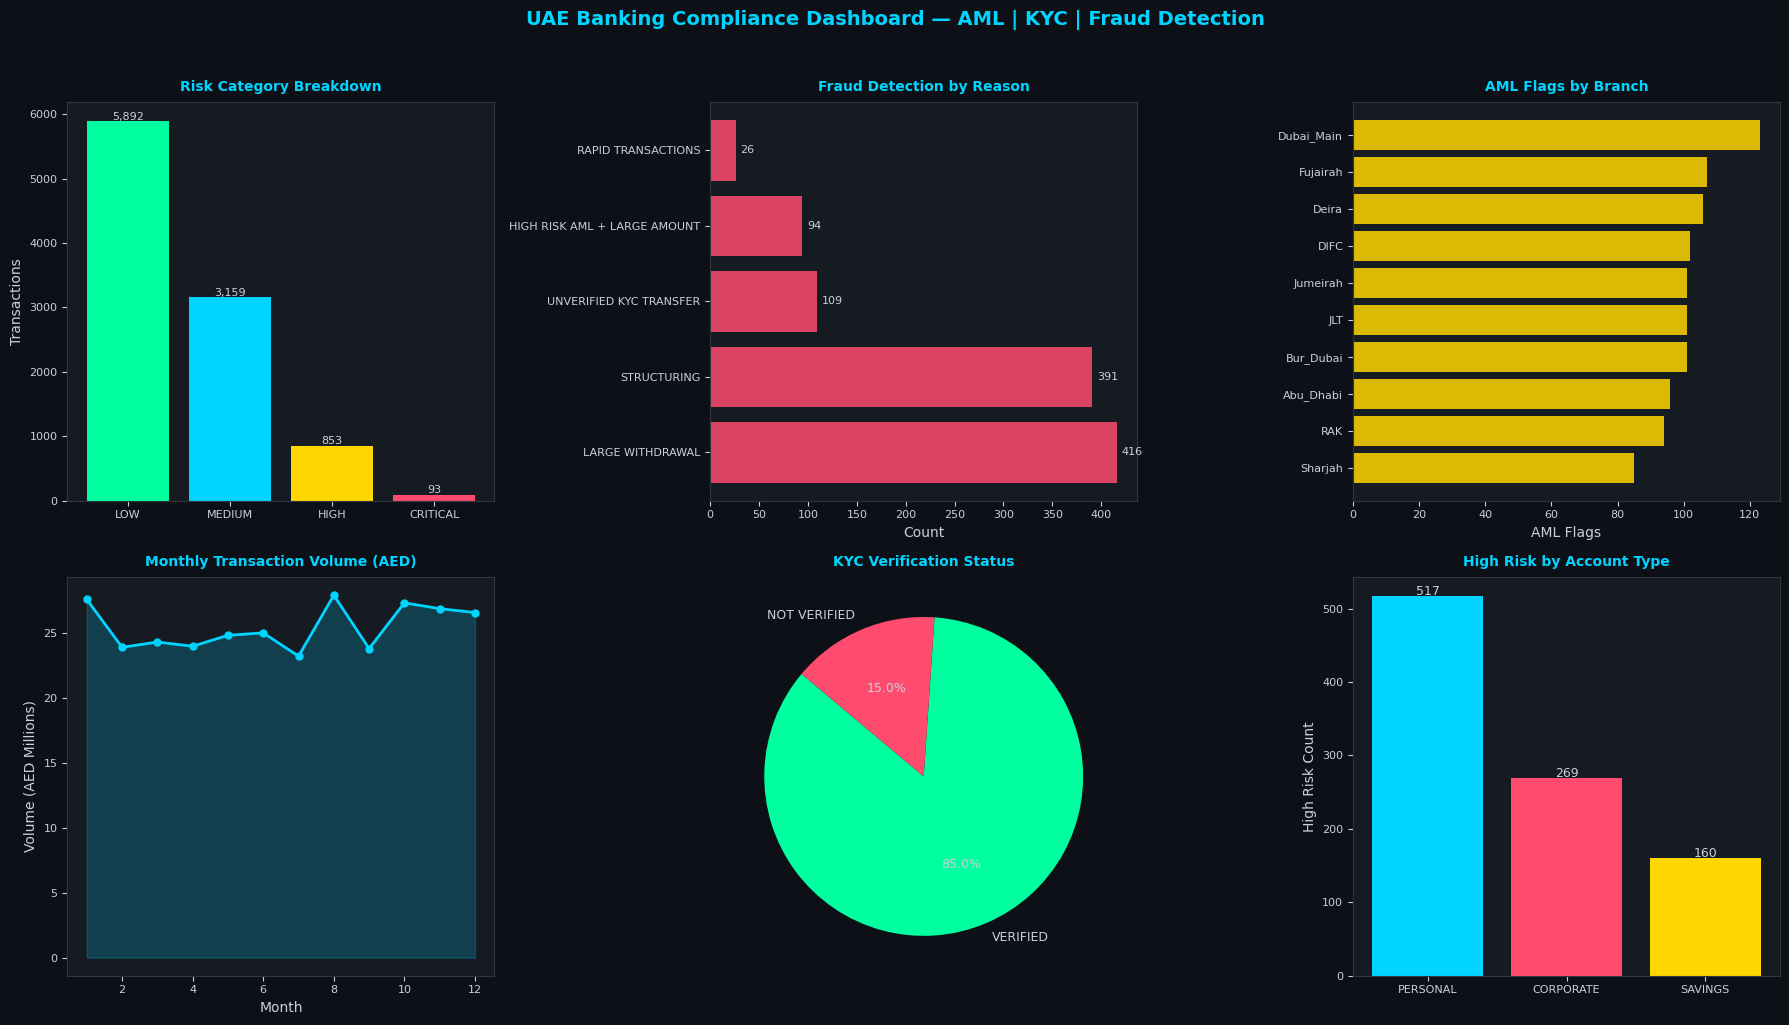

✅ Dashboard displayed & saved!


In [7]:


def build_dashboard(df):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.patch.set_facecolor("#0D1117")
    fig.suptitle("UAE Banking Compliance Dashboard — AML | KYC | Fraud Detection",
                 fontsize=14, fontweight="bold", color="#00D4FF", y=1.02)

    BG   = "#161B22"
    TEXT = "#C9D1D9"
    BLUE = "#00D4FF"
    GREEN = "#00FF9F"
    RED  = "#FF4B6E"
    GOLD = "#FFD700"

    def style(ax, title):
        ax.set_facecolor(BG)
        ax.set_title(title, color=BLUE, fontweight="bold", fontsize=10, pad=8)
        ax.tick_params(colors=TEXT, labelsize=8)
        for sp in ax.spines.values():
            sp.set_edgecolor("#30363D")
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)

    # ── Chart 1: Risk Category Breakdown ──
    ax1 = axes[0, 0]
    style(ax1, "Risk Category Breakdown")
    risk = df["risk_category"].value_counts()
    colors = [GREEN, BLUE, GOLD, RED]
    bars = ax1.bar(risk.index, risk.values, color=colors)
    for bar, val in zip(bars, risk.values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f"{val:,}", ha="center", color=TEXT, fontsize=8)
    ax1.set_ylabel("Transactions")

    # ── Chart 2: Fraud by Reason ──
    ax2 = axes[0, 1]
    style(ax2, "Fraud Detection by Reason")
    fraud_df = df[df["fraud_flag"]==1]["fraud_reason"].value_counts()
    ax2.barh(fraud_df.index, fraud_df.values, color=RED, alpha=0.85)
    ax2.set_xlabel("Count")
    for i, val in enumerate(fraud_df.values):
        ax2.text(val + 5, i, f"{val:,}", va="center", color=TEXT, fontsize=8)

    # ── Chart 3: AML by Branch ──
    ax3 = axes[0, 2]
    style(ax3, "AML Flags by Branch")
    branch_aml = df.groupby("branch")["aml_flag"].sum().sort_values(ascending=True)
    ax3.barh(branch_aml.index, branch_aml.values, color=GOLD, alpha=0.85)
    ax3.set_xlabel("AML Flags")

    # ── Chart 4: Monthly Transaction Volume ──
    ax4 = axes[1, 0]
    style(ax4, "Monthly Transaction Volume (AED)")
    df["month"] = pd.to_datetime(df["transaction_date"]).dt.month
    monthly = df.groupby("month")["amount_aed"].sum() / 1e6
    ax4.plot(monthly.index, monthly.values, color=BLUE,
             linewidth=2, marker="o", markersize=5)
    ax4.fill_between(monthly.index, monthly.values, alpha=0.2, color=BLUE)
    ax4.set_xlabel("Month")
    ax4.set_ylabel("Volume (AED Millions)")

    # ── Chart 5: KYC Status ──
    ax5 = axes[1, 1]
    style(ax5, "KYC Verification Status")
    kyc = df["kyc_status"].value_counts()
    ax5.pie(kyc.values,
            labels=kyc.index,
            colors=[GREEN, RED],
            autopct="%1.1f%%",
            textprops={"color": TEXT, "fontsize": 9},
            startangle=140)

    # ── Chart 6: Risk by Account Type ──
    ax6 = axes[1, 2]
    style(ax6, "High Risk by Account Type")
    high_risk = df[df["risk_category"].isin(["HIGH","CRITICAL"])]
    acc_risk = high_risk["account_type"].value_counts()
    ax6.bar(acc_risk.index, acc_risk.values,
            color=[BLUE, RED, GOLD])
    ax6.set_ylabel("High Risk Count")
    for i, (idx, val) in enumerate(acc_risk.items()):
        ax6.text(i, val + 2, f"{val:,}", ha="center", color=TEXT, fontsize=9)

    plt.tight_layout()
    plt.savefig("compliance_dashboard.png", dpi=150,
                bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()
    print("✅ Dashboard displayed & saved!")

build_dashboard(df_clean)

Final Compliance Report

In [8]:


def generate_compliance_report(df):
    total         = len(df)
    total_aed     = df["amount_aed"].sum()
    aml_flagged   = df["aml_flag"].sum()
    kyc_fail      = (df["kyc_verified"] == 0).sum()
    fraud_total   = df["fraud_flag"].sum()
    high_risk     = (df["risk_category"] == "HIGH").sum()
    critical      = (df["risk_category"] == "CRITICAL").sum()
    top_branch    = df.groupby("branch")["aml_flag"].sum().idxmax()
    top_fraud     = df[df["fraud_flag"]==1]["fraud_reason"].value_counts().idxmax()

    report = f"""
╔═══════════════════════════════════════════════════════════╗
║     UAE BANKING COMPLIANCE REPORT — {datetime.now().strftime("%Y-%m-%d")}            ║
║     Prepared by: Automated Compliance System              ║
╚═══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Transactions Processed : {total:,}
  Total Volume (AED)           : AED {total_aed:,.2f}
  Report Generated             : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. AML MONITORING RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔴 AML Flagged Transactions  : {aml_flagged:,} ({100*aml_flagged/total:.1f}%)
  ⚠️  KYC Not Verified          : {kyc_fail:,} ({100*kyc_fail/total:.1f}%)
  🏦 Highest Risk Branch       : {top_branch}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. FRAUD DETECTION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚨 Total Fraud Detected      : {fraud_total:,} ({100*fraud_total/total:.1f}%)
  🔍 Top Fraud Pattern         : {top_fraud}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. RISK BREAKDOWN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{df['risk_category'].value_counts().to_string()}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. RECOMMENDATIONS TO COMPLIANCE TEAM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. Immediately review {critical:,} CRITICAL risk transactions
  2. Block {kyc_fail:,} unverified KYC accounts for large transfers
  3. Investigate {aml_flagged:,} AML flagged transactions
  4. Focus audit on {top_branch} branch (highest risk)
  5. Review all STRUCTURING patterns urgently

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. REGULATORY COMPLIANCE STATUS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✅ AML Monitoring             : ACTIVE
  ✅ KYC Verification Check     : ACTIVE
  ✅ Fraud Detection            : ACTIVE
  ✅ SQLite Database            : SAVED
  ✅ Dashboard                  : GENERATED
  ✅ CBUAE Reporting Ready      : YES

Pipeline Status : ✅ COMPLETED SUCCESSFULLY
═══════════════════════════════════════════════════════════
    """

    print(report)

    # Save report
    with open("compliance_report.txt", "w") as f:
        f.write(report)
    print("✅ Report saved: compliance_report.txt")

generate_compliance_report(df_clean)


╔═══════════════════════════════════════════════════════════╗
║     UAE BANKING COMPLIANCE REPORT — 2026-06-02            ║
║     Prepared by: Automated Compliance System              ║
╚═══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total Transactions Processed : 10,000
  Total Volume (AED)           : AED 305,286,530.93
  Report Generated             : 2026-06-02 12:24:42

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. AML MONITORING RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔴 AML Flagged Transactions  : 1,016 (10.2%)
  ⚠️  KYC Not Verified          : 1,497 (15.0%)
  🏦 Highest Risk Branch       : Dubai_Main

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. FRAUD DETECTION RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🚨 Total Fraud Detected      : 1,036 (10.4%